In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!curl -X GET 'https://api.binance.com/api/v3/ticker/price?symbol=BTCUSDT'

{
  "code": 0,
  "msg": "Service unavailable from a restricted location according to 'b. Eligibility' in https://www.binance.com/en/terms. Please contact customer service if you believe you received this message in error."
}

In [3]:
!pip install free-proxy

  Preparing metadata (setup.py) ... done
  Created wheel for free-proxy: filename=free_proxy-1.1.3-py3-none-any.whl size=6097 sha256=74fb2c6c9785561dcb701c10523c96515dad136708d6c20fa21d16be226e2f1b
  Stored in directory: /root/.cache/pip/wheels/b1/5b/61/c93b717842c89aac55d0590076f64041825eb8d89712fca95a
Successfully built free-proxy


In [4]:
from fp.fp import FreeProxy
import requests

# Automatically gets the first working proxy from a public list
proxy = FreeProxy(https=True).get() 

proxies = {
    "http": proxy,
    "https": proxy
}

response = requests.get("https://httpbin.org/ip", proxies=proxies)
print(f"Using proxy: {proxy}")
print(response.json())

FreeProxyException: There are no working proxies at this time.

## Section 0: Setup & Installs

In [6]:
# ─────────────────────────────────────────────
# SECTION 0.1 — Package Installation
# Run once per Kaggle session
# ─────────────────────────────────────────────

!pip install -q \
    google-adk \
    pymongo \
    faster-whisper \
    yt-dlp \
    feedparser \
    python-telegram-bot \
    pydantic \
    httpx \
    litellm \
    dnspython \
    certifi

print("✅ All packages installed")

✅ All packages installed


In [7]:
# ─────────────────────────────────────────────
# SECTION 0.2 — Imports
# ─────────────────────────────────────────────

# Standard library
import os
import json
import asyncio
import logging
from datetime import datetime, date, timedelta
from typing import Optional
from zoneinfo import ZoneInfo

# Data & validation
from pydantic import BaseModel, Field

# Database
from pymongo import MongoClient
from pymongo.collection import Collection

# HTTP
import httpx
import feedparser

# Telegram
from telegram import Bot

# LLM — Gemini
from google import genai
from google.genai import types

# LLM — LiteLLM (for OpenRouter switching)
import litellm

# ADK
from google.adk.agents import LlmAgent
from google.adk.tools import FunctionTool
from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService

# Whisper transcription
from faster_whisper import WhisperModel

# Logging setup
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s"
)
log = logging.getLogger(__name__)

print("✅ Imports OK")

✅ Imports OK


In [8]:
# ─────────────────────────────────────────────
# SECTION 0.3 — Secrets & Environment Variables
# In Kaggle: Add > Secrets (left sidebar)
# Toggle "Attach to notebook" for each one
# ─────────────────────────────────────────────

from kaggle_secrets import UserSecretsClient
secrets = UserSecretsClient()

def get_secret(key: str, fallback: str = "") -> str:
    try:
        return secrets.get_secret(key)
    except Exception:
        log.warning(f"Secret '{key}' not found, using fallback")
        return fallback

# Load all secrets into env vars
os.environ["MONGODB_URI"]        = get_secret("MONGODB_URI")
os.environ["GOOGLE_API_KEY"]     = get_secret("GEMINI_API_KEY")
os.environ["OPENROUTER_API_KEY"] = get_secret("OPENROUTER_API_KEY")  # optional
os.environ["TELEGRAM_BOT_TOKEN"] = get_secret("TELEGRAM_TOKEN")
os.environ["TELEGRAM_CHAT_ID"]   = get_secret("TELEGRAM_CHAT_ID")
os.environ["HF_TOKEN"]   = get_secret("HF_TOKEN")

# LLM provider config — change these to switch models
os.environ["LLM_PROVIDER"] = "gemini"                  # "gemini" or "openrouter"
os.environ["LLM_MODEL"]    = "gemini-flash-lite-latest"        # or "anthropic/claude-sonnet-4-5"

# Configure Gemini SDK
# genai.configure(api_key=os.environ["GOOGLE_API_KEY"])
# NEW — replace with:
gemini_client = genai.Client(api_key=os.environ["GOOGLE_API_KEY"])

print("✅ Secrets loaded")
print(f"   LLM  : {os.environ['LLM_PROVIDER']} / {os.environ['LLM_MODEL']}")
print(f"   Mongo: {'set' if os.environ['MONGODB_URI'] else '⚠️ MISSING'}")
print(f"   TG   : {'set' if os.environ['TELEGRAM_BOT_TOKEN'] else '⚠️ MISSING'}")

✅ Secrets loaded
   LLM  : gemini / gemini-flash-lite-latest
   Mongo: set
   TG   : set


In [9]:
# ─────────────────────────────────────────────
# SECTION 0.4 — Constants & Configuration
# ─────────────────────────────────────────────

# ── YouTube Channels ──────────────────────────
CHANNELS = [
    {"id": "UCgY66N1YS_G9lYMvCQko6yw", "name": "CryptoWorldJosh",  "url": "https://youtube.com/@cryptoworldjosh"},
    {"id": "UC8QWLZNoN3whQ7QMwoDp78A", "name": "CilinixCrypto",    "url": "https://youtube.com/@cilinixcrypto"},
    {"id": "UCoUcIy0SWXXIhzWgJNdMoFQ", "name": "CryptoRover",      "url": "https://youtube.com/@cryptorover"},
    {"id": "UCd-Rt1oQGAVjOdwPVYsZbjQ", "name": "TheRoadTo1M",      "url": "https://youtube.com/@theroadto1m"},
    {"id": "UCBjrrP9frGRuRwoAJ4RQdag", "name": "CryptoJackk",      "url": "https://youtube.com/@cryptojackk"},
]

# ── Paths ─────────────────────────────────────
WORKING_DIR  = "/kaggle/working"
AUDIO_DIR    = f"{WORKING_DIR}/audio"        # deleted after transcription
os.makedirs(AUDIO_DIR, exist_ok=True)

# ── Transcription ─────────────────────────────
WHISPER_MODEL_SIZE  = "large-v3-turbo"
WHISPER_DEVICE      = "cuda"                 # Kaggle P100
WHISPER_COMPUTE     = "float32"

# ── Price / Binance ───────────────────────────
BINANCE_BASE_URL    = "https://api.binance.com"
BTC_SYMBOL          = "BTCUSDT"
PRICE_HISTORY_DAYS  = 30

# ── MongoDB ───────────────────────────────────
DB_NAME = "btc_agent"
COLLECTIONS = {
    "processed_videos" : "processed_videos",
    "daily_analyses"   : "daily_analyses",
    "predictions"      : "predictions",
    "technique_ledger" : "technique_ledger",
    "agent_memory"     : "agent_memory",
    "agent_opinions"   : "agent_opinions",
}

# ── Agent / Memory ────────────────────────────
MEMORY_WINDOW_DAYS  = 7     # days of analyses agent can look back
PREDICTION_MAX_DAYS = 14    # max days ahead a prediction can target

# ── Timezone ──────────────────────────────────
TZ = ZoneInfo("UTC")

# ── Extraction schema version ─────────────────
# Bump this if you change the extraction format,
# so old docs and new docs can be told apart
SCHEMA_VERSION = "1.0"

print("✅ Constants set")
print(f"   Channels  : {len(CHANNELS)}")
print(f"   Audio dir : {AUDIO_DIR}")
print(f"   Whisper   : {WHISPER_MODEL_SIZE} on {WHISPER_DEVICE}")
print(f"   DB        : {DB_NAME}")

✅ Constants set
   Channels  : 5
   Audio dir : /kaggle/working/audio
   Whisper   : large-v3-turbo on cuda
   DB        : btc_agent


In [10]:
# ─────────────────────────────────────────────
# SECTION 0.5 — ✅ Test: Verify Setup
# ─────────────────────────────────────────────

print("=" * 50)
print("SETUP VERIFICATION")
print("=" * 50)

# 1. Check GPU
try:
    import torch
    gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"
    print(f"GPU       : {gpu}")
except:
    print("GPU       : torch not available")

# 2. Check Gemini reachable
try:
    # model = genai.GenerativeModel("gemini-2.5-flash")
    # resp  = model.generate_content("Reply with only the word PONG")
    # print(f"Gemini    : {resp.text.strip()}")
    # NEW — replace with:
    resp = gemini_client.models.generate_content(
        model="gemini-flash-lite-latest",
        contents="Reply with only the word PONG"
    )
    print(f"Gemini    : {resp.text.strip()}")
except Exception as e:
    print(f"Gemini    : ⚠️  {e}")

# 3. Check Mongo URI is set
mongo_uri = os.environ.get("MONGODB_URI", "")
print(f"Mongo URI : {'set ✅' if mongo_uri.startswith('mongodb') else '⚠️ not set'}")

# 4. Check Telegram token
tg_token = os.environ.get("TELEGRAM_BOT_TOKEN", "")
print(f"Telegram  : {'set ✅' if tg_token else '⚠️ not set'}")

# 5. Check audio dir
print(f"Audio dir : {AUDIO_DIR} ({'exists ✅' if os.path.exists(AUDIO_DIR) else '⚠️ missing'})")

# 6. List channels
print(f"\nChannels ({len(CHANNELS)}):")
for ch in CHANNELS:
    print(f"  - {ch['name']:20s}  {ch['id']}")

print("=" * 50)

SETUP VERIFICATION
GPU       : Tesla P100-PCIE-16GB


/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 Tesla P100-PCIE-16GB which is of cuda capability 6.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
Tesla P100-PCIE-16GB with CUDA capability sm_60 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Tesla P100-PCIE-16GB GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_call()


Gemini    : PONG
Mongo URI : set ✅
Telegram  : set ✅
Audio dir : /kaggle/working/audio (exists ✅)

Channels (5):
  - CryptoWorldJosh       UCgY66N1YS_G9lYMvCQko6yw
  - CilinixCrypto         UC8QWLZNoN3whQ7QMwoDp78A
  - CryptoRover           UCoUcIy0SWXXIhzWgJNdMoFQ
  - TheRoadTo1M           UCd-Rt1oQGAVjOdwPVYsZbjQ
  - CryptoJackk           UCBjrrP9frGRuRwoAJ4RQdag


## SECTION 1: Database (MongoDB) 

In [11]:
# ─────────────────────────────────────────────
# SECTION 1.1 — MongoDB Connection
# ─────────────────────────────────────────────

from pymongo import MongoClient
from pymongo.errors import ConnectionFailure

def get_db():
    client = MongoClient(os.environ["MONGODB_URI"])
    return client[DB_NAME]

# Establish connection once, reuse across sections
db = get_db()

print("✅ MongoDB connected")
print(f"   Database: {DB_NAME}")

✅ MongoDB connected
   Database: btc_agent


In [12]:
# ─────────────────────────────────────────────
# SECTION 1.2 — Pydantic Schemas
# These are the canonical field names used
# everywhere — extraction, DB, agent tools
# ─────────────────────────────────────────────

from pydantic import BaseModel, Field
from typing import Optional
from datetime import date

# ── Technique ─────────────────────────────────
class Technique(BaseModel):
    name: str                          # e.g. "RSI divergence"
    timeframe: Optional[str] = None                     # e.g. "4H", "1D"
    signal: str                        # "bullish", "bearish", "neutral"

# ── Prediction ────────────────────────────────
class ScenarioPrediction(BaseModel):
    label: str                         # "bull case", "bear case", "base case"
    condition: str                     # "if BTC holds $98k"
    target: Optional[float] = None     # 112000.0
    probability: Optional[str] = None  # "60%"

class Predictions(BaseModel):
    # Primary — used for automated scoring
    primary: Optional[dict] = Field(default=None, description={
        "scenario"    : "string — the condition e.g. 'if holds $98k'",
        "direction"   : "up | down | sideways",
        "target"      : "float — price target",
        "timeframe"   : "string — e.g. '7-14 days'",
        "confidence"  : "high | medium | low",
        "invalidation": "string — e.g. 'daily close below $96k'"
    })
    scenarios: list[ScenarioPrediction] = []   # bull/base/bear cases
    short_term: Optional[str] = None           # free text, next 1-3 days
    long_term:  Optional[str] = None           # free text, weeks/months
    narrative:  Optional[str] = None           # anything that doesn't fit above

# ── Key Levels ────────────────────────────────
class KeyLevels(BaseModel):
    support:    list[float] = []
    resistance: list[float] = []

# ── Daily Analysis ────────────────────────────
class DailyAnalysis(BaseModel):
    video_id:             str
    channel_id:           str
    channel_name:         str
    analysis_date:        str                  # "YYYY-MM-DD"
    schema_version:       str = SCHEMA_VERSION
    btc_price_mentioned:  Optional[float] = None
    market_structure:     Optional[str]  = None  # bullish|bearish|ranging|unclear
    techniques_used:      list[Technique] = []
    predictions:          Predictions = Field(default_factory=Predictions)
    key_levels:           KeyLevels = Field(default_factory=KeyLevels)
    catalysts:            list[str] = []
    contrarian_view:      Optional[str] = None
    raw_transcription:    Optional[str] = None   # stored only if < 8000 chars

# ── Prediction Record (for scoring) ──────────
class PredictionRecord(BaseModel):
    video_id:       str
    channel_name:   str
    prediction_date: str                 # "YYYY-MM-DD"
    direction:      str                  # up | down | sideways
    target:         float
    timeframe:      str
    target_date:    str                  # "YYYY-MM-DD" — when to score
    confidence:     str
    invalidation:   Optional[str] = None
    # Filled in later by price scoring
    actual_price:   Optional[float] = None
    outcome:        Optional[str]  = None  # correct|partial|wrong|invalidated
    accuracy_score: Optional[float] = None # 0.0 - 1.0

# ── Technique Ledger Entry ────────────────────
class TechniqueLedgerEntry(BaseModel):
    technique_name:       str
    description:          Optional[str] = None
    times_used:           int = 0
    correct_calls:        int = 0
    hit_rate:             float = 0.0
    best_market_condition: Optional[str] = None
    recent_examples:      list[dict] = []
    last_updated:         str = ""

# ── Agent Memory ──────────────────────────────
class AgentMemory(BaseModel):
    last_updated:          str = ""
    market_narrative:      str = ""
    key_levels_consensus:  KeyLevels = Field(default_factory=KeyLevels)
    technique_insights:    list[str] = []
    channel_reliability:   dict = {}    # {channel_name: {accuracy: float, note: str}}
    open_predictions:      list[dict] = []
    agent_current_view:    str = ""
    agent_reflection:      str = ""

# ── Agent Opinion ─────────────────────────────
class AgentOpinion(BaseModel):
    opinion_date:    str
    direction:       str
    price_target:    Optional[float] = None
    reasoning:       str
    techniques_cited: list[str] = []
    actual_price:    Optional[float] = None
    outcome:         Optional[str]  = None
    reflection:      Optional[str]  = None

print("✅ Schemas defined")
print(f"   Models: DailyAnalysis, Predictions, PredictionRecord,")
print(f"           TechniqueLedgerEntry, AgentMemory, AgentOpinion")

✅ Schemas defined
   Models: DailyAnalysis, Predictions, PredictionRecord,
           TechniqueLedgerEntry, AgentMemory, AgentOpinion


In [13]:
# ─────────────────────────────────────────────
# SECTION 1.3 — Collection Helpers (CRUD)
# All DB operations go through these functions
# ─────────────────────────────────────────────

# ── processed_videos ──────────────────────────

def is_video_processed(video_id: str) -> bool:
    return db[COLLECTIONS["processed_videos"]].find_one({"video_id": video_id}) is not None

def mark_video_processed(video_id: str, channel_id: str, channel_name: str, title: str, published_at: str):
    db[COLLECTIONS["processed_videos"]].update_one(
        {"video_id": video_id},
        {"$set": {
            "video_id":     video_id,
            "channel_id":   channel_id,
            "channel_name": channel_name,
            "title":        title,
            "published_at": published_at,
            "processed_at": datetime.now(TZ).isoformat(),
            "status":       "done"
        }},
        upsert=True
    )

# ── daily_analyses ────────────────────────────

def save_analysis(analysis: DailyAnalysis):
    doc = analysis.model_dump()
    db[COLLECTIONS["daily_analyses"]].update_one(
        {"video_id": analysis.video_id},
        {"$set": doc},
        upsert=True
    )

def get_analyses_by_date(analysis_date: str) -> list[dict]:
    return list(db[COLLECTIONS["daily_analyses"]].find(
        {"analysis_date": analysis_date},
        {"_id": 0}
    ))

def get_analyses_last_n_days(n: int) -> list[dict]:
    since = (date.today() - timedelta(days=n)).isoformat()
    return list(db[COLLECTIONS["daily_analyses"]].find(
        {"analysis_date": {"$gte": since}},
        {"_id": 0}
    ).sort("analysis_date", -1))

def get_raw_analysis(video_id: str) -> Optional[dict]:
    return db[COLLECTIONS["daily_analyses"]].find_one(
        {"video_id": video_id},
        {"_id": 0}
    )

# ── predictions ───────────────────────────────

def save_prediction(pred: PredictionRecord):
    doc = pred.model_dump()
    db[COLLECTIONS["predictions"]].update_one(
        {"video_id": pred.video_id, "target_date": pred.target_date},
        {"$set": doc},
        upsert=True
    )

def get_pending_predictions(as_of_date: Optional[str] = None) -> list[dict]:
    """Predictions whose target_date has passed but aren't scored yet."""
    as_of = as_of_date or date.today().isoformat()
    return list(db[COLLECTIONS["predictions"]].find(
        {"target_date": {"$lte": as_of}, "outcome": None},
        {"_id": 0}
    ))

def update_prediction_outcome(video_id: str, target_date: str, actual_price: float, outcome: str, accuracy_score: float):
    db[COLLECTIONS["predictions"]].update_one(
        {"video_id": video_id, "target_date": target_date},
        {"$set": {
            "actual_price":   actual_price,
            "outcome":        outcome,
            "accuracy_score": accuracy_score
        }}
    )

def get_scored_predictions(n_days: int = 14) -> list[dict]:
    since = (date.today() - timedelta(days=n_days)).isoformat()
    return list(db[COLLECTIONS["predictions"]].find(
        {"prediction_date": {"$gte": since}, "outcome": {"$ne": None}},
        {"_id": 0}
    ).sort("prediction_date", -1))

# ── technique_ledger ──────────────────────────

def get_technique_ledger() -> list[dict]:
    return list(db[COLLECTIONS["technique_ledger"]].find({}, {"_id": 0}))

def upsert_technique(entry: TechniqueLedgerEntry):
    doc = entry.model_dump()
    doc["last_updated"] = datetime.now(TZ).isoformat()
    db[COLLECTIONS["technique_ledger"]].update_one(
        {"technique_name": entry.technique_name},
        {"$set": doc},
        upsert=True
    )

# ── agent_memory ──────────────────────────────

def get_agent_memory() -> Optional[AgentMemory]:
    doc = db[COLLECTIONS["agent_memory"]].find_one({}, {"_id": 0})
    if doc:
        return AgentMemory(**doc)
    return AgentMemory()  # return empty memory if first run

def save_agent_memory(memory: AgentMemory):
    doc = memory.model_dump()
    doc["last_updated"] = datetime.now(TZ).isoformat()
    db[COLLECTIONS["agent_memory"]].replace_one(
        {},           # only ever one document
        doc,
        upsert=True
    )

# ── agent_opinions ────────────────────────────

def save_agent_opinion(opinion: AgentOpinion):
    doc = opinion.model_dump()
    db[COLLECTIONS["agent_opinions"]].update_one(
        {"opinion_date": opinion.opinion_date},
        {"$set": doc},
        upsert=True
    )

def get_agent_opinions(n_days: int = 14) -> list[dict]:
    since = (date.today() - timedelta(days=n_days)).isoformat()
    return list(db[COLLECTIONS["agent_opinions"]].find(
        {"opinion_date": {"$gte": since}},
        {"_id": 0}
    ).sort("opinion_date", -1))

print("✅ DB helpers defined")
print("   processed_videos : is_video_processed, mark_video_processed")
print("   daily_analyses   : save_analysis, get_analyses_by_date,")
print("                      get_analyses_last_n_days, get_raw_analysis")
print("   predictions      : save_prediction, get_pending_predictions,")
print("                      update_prediction_outcome, get_scored_predictions")
print("   technique_ledger : get_technique_ledger, upsert_technique")
print("   agent_memory     : get_agent_memory, save_agent_memory")
print("   agent_opinions   : save_agent_opinion, get_agent_opinions")

✅ DB helpers defined
   processed_videos : is_video_processed, mark_video_processed
   daily_analyses   : save_analysis, get_analyses_by_date,
                      get_analyses_last_n_days, get_raw_analysis
   predictions      : save_prediction, get_pending_predictions,
                      update_prediction_outcome, get_scored_predictions
   technique_ledger : get_technique_ledger, upsert_technique
   agent_memory     : get_agent_memory, save_agent_memory
   agent_opinions   : save_agent_opinion, get_agent_opinions


In [14]:
# ─────────────────────────────────────────────
# SECTION 1.4 — ✅ Test: Database
# ─────────────────────────────────────────────

print("=" * 50)
print("DATABASE VERIFICATION")
print("=" * 50)

# 1. Ping
try:
    db.command("ping")
    print("✅ Ping OK")
except Exception as e:
    print(f"❌ Ping failed: {e}")

# 2. Show existing collections
cols = db.list_collection_names()
print(f"\nExisting collections ({len(cols)}):")
for c in cols if cols else ["(none yet — will be created on first write)"]:
    print(f"  - {c}")

# 3. Test write → read → delete on processed_videos
test_id = "_test_video_001"
mark_video_processed(test_id, "test_channel", "TestChannel", "Test Video", "2025-01-01")
assert is_video_processed(test_id), "Write/read failed"
db[COLLECTIONS["processed_videos"]].delete_one({"video_id": test_id})
assert not is_video_processed(test_id), "Delete failed"
print("\n✅ Write / Read / Delete OK")

# 4. Test agent_memory round-trip
test_mem = AgentMemory(
    market_narrative="Test narrative",
    agent_current_view="Neutral for testing"
)
save_agent_memory(test_mem)
loaded = get_agent_memory()
assert loaded.market_narrative == "Test narrative", "Memory round-trip failed"
print("✅ AgentMemory round-trip OK")

# 5. Show memory doc as it sits in DB
print("\nCurrent agent_memory doc:")
print(json.dumps(loaded.model_dump(), indent=2))

print("\n" + "=" * 50)

DATABASE VERIFICATION
✅ Ping OK

Existing collections (5):
  - predictions
  - agent_opinions
  - agent_memory
  - processed_videos
  - daily_analyses

✅ Write / Read / Delete OK
✅ AgentMemory round-trip OK

Current agent_memory doc:
{
  "last_updated": "2026-05-20T15:11:18.867869+00:00",
  "market_narrative": "Test narrative",
  "key_levels_consensus": {
    "support": [],
    "resistance": []
  },
  "technique_insights": [],
  "channel_reliability": {},
  "open_predictions": [],
  "agent_current_view": "Neutral for testing",
  "agent_reflection": ""
}



## SECTION 2: Price Data

In [15]:
# ─────────────────────────────────────────────
# SECTION 2.1 — Binance Price Data
# No API key needed for public OHLCV endpoint
# ─────────────────────────────────────────────

import httpx
from datetime import timezone

def fetch_btc_ohlcv(days: int = PRICE_HISTORY_DAYS) -> list[dict]:
    """
    Fetch BTCUSDT daily OHLCV from Binance.
    Returns list of dicts sorted oldest → newest.
    Each dict: {date, open, high, low, close, volume}
    """
    url    = f"{BINANCE_BASE_URL}/api/v3/klines"
    params = {
        "symbol":   BTC_SYMBOL,
        "interval": "1d",
        "limit":    days
    }

    with httpx.Client(timeout=15) as client:
        resp = client.get(url, params=params)
        resp.raise_for_status()

    candles = []
    for k in resp.json():
        open_time = datetime.fromtimestamp(k[0] / 1000, tz=timezone.utc)
        candles.append({
            "date":   open_time.strftime("%Y-%m-%d"),
            "open":   float(k[1]),
            "high":   float(k[2]),
            "low":    float(k[3]),
            "close":  float(k[4]),
            "volume": float(k[5]),
        })

    return candles


def get_price_on_date(target_date: str, candles: list[dict]) -> Optional[float]:
    """
    Get BTC closing price for a specific date string 'YYYY-MM-DD'.
    Returns None if date not found in candles.
    """
    for c in candles:
        if c["date"] == target_date:
            return c["close"]
    return None


def get_latest_price(candles: list[dict]) -> dict:
    """Returns the most recent candle."""
    return candles[-1] if candles else {}


print("✅ Binance fetch functions defined")
print("   fetch_btc_ohlcv(days)")
print("   get_price_on_date(target_date, candles)")
print("   get_latest_price(candles)")

✅ Binance fetch functions defined
   fetch_btc_ohlcv(days)
   get_price_on_date(target_date, candles)
   get_latest_price(candles)


In [16]:
# ─────────────────────────────────────────────
# SECTION 2.2 — Prediction Scoring
# Runs daily: scores any predictions whose
# target_date has passed
# ─────────────────────────────────────────────

def score_single_prediction(pred: dict, actual_price: float) -> tuple[str, float]:
    """
    Score one prediction against actual price.

    Scoring rules:
    - correct     : price moved in right direction AND within 3% of target
    - partial     : price moved in right direction but missed target by 3-10%
    - wrong       : price moved in wrong direction
    - invalidated : price hit the invalidation level before target_date

    Returns (outcome, accuracy_score 0.0-1.0)
    """
    target    = pred.get("target")
    direction = pred.get("direction", "").lower()

    if not target or not direction:
        return ("unscored", 0.0)

    price_change_pct = (actual_price - pred.get("entry_price", actual_price)) / max(actual_price, 1)
    distance_pct     = abs(actual_price - target) / target

    moved_up   = actual_price > (pred.get("entry_price") or actual_price)
    moved_down = actual_price < (pred.get("entry_price") or actual_price)

    if direction == "up":
        direction_correct = actual_price >= (pred.get("entry_price") or 0)
    elif direction == "down":
        direction_correct = actual_price <= (pred.get("entry_price") or float("inf"))
    else:  # sideways
        direction_correct = distance_pct < 0.05

    if not direction_correct:
        return ("wrong", 0.0)

    if distance_pct <= 0.03:
        return ("correct", 1.0)
    elif distance_pct <= 0.10:
        # Partial — score scales 0.5-0.9 based on how close
        accuracy = round(0.9 - (distance_pct / 0.10) * 0.4, 2)
        return ("partial", accuracy)
    else:
        return ("partial", 0.3)


def score_pending_predictions(candles: list[dict]) -> dict:
    """
    Fetch all unscored predictions whose target_date <= today.
    Score each one, update MongoDB, return summary.
    """
    pending = get_pending_predictions()

    if not pending:
        log.info("No pending predictions to score")
        return {"scored": 0, "results": []}

    results = []
    for pred in pending:
        target_date  = pred.get("target_date")
        actual_price = get_price_on_date(target_date, candles)

        if actual_price is None:
            log.warning(f"No price data for {target_date}, skipping")
            continue

        outcome, accuracy = score_single_prediction(pred, actual_price)

        update_prediction_outcome(
            video_id      = pred["video_id"],
            target_date   = target_date,
            actual_price  = actual_price,
            outcome       = outcome,
            accuracy_score= accuracy
        )

        results.append({
            "channel":     pred.get("channel_name"),
            "target":      pred.get("target"),
            "actual":      actual_price,
            "outcome":     outcome,
            "accuracy":    accuracy
        })

        log.info(f"Scored [{pred.get('channel_name')}] target={pred.get('target')} "
                 f"actual={actual_price} → {outcome} ({accuracy})")

    return {"scored": len(results), "results": results}


print("✅ Scoring functions defined")
print("   score_single_prediction(pred, actual_price)")
print("   score_pending_predictions(candles)")

✅ Scoring functions defined
   score_single_prediction(pred, actual_price)
   score_pending_predictions(candles)


PRICE DATA VERIFICATION

✅ Fetched 30 daily candles

Latest candle:
  Date   : 2026-05-20
  Open   : $76,834.36
  High   : $77,748.05
  Low    : $76,516.74
  Close  : $77,335.40
  Volume : 7,790

✅ Scoring test:
  channel=TestChannel target=78,109 actual=77,335 → correct (score=1.0)
   Test prediction cleaned up


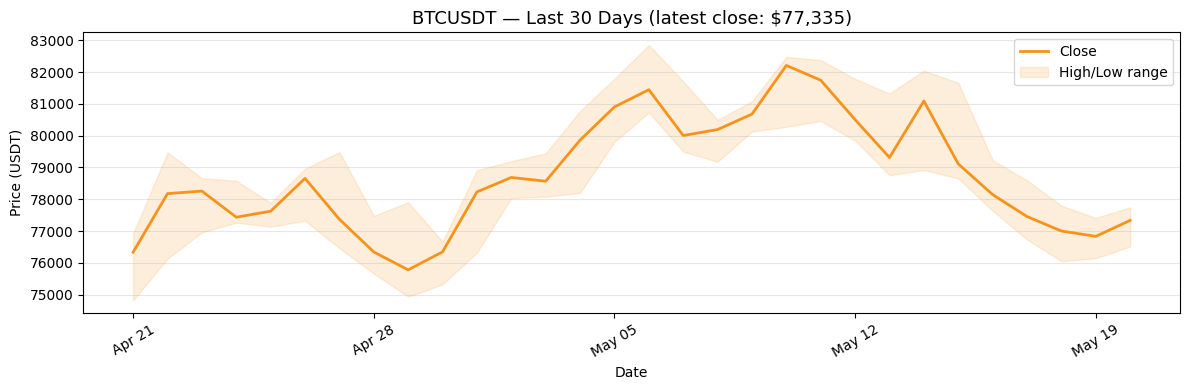

In [17]:
# ─────────────────────────────────────────────
# SECTION 2.3 — ✅ Test: Price Data
# ─────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime as dt

print("=" * 50)
print("PRICE DATA VERIFICATION")
print("=" * 50)

# 1. Fetch candles
candles = fetch_btc_ohlcv(days=30)
print(f"\n✅ Fetched {len(candles)} daily candles")

# 2. Show latest
latest = get_latest_price(candles)
print(f"\nLatest candle:")
print(f"  Date   : {latest['date']}")
print(f"  Open   : ${latest['open']:,.2f}")
print(f"  High   : ${latest['high']:,.2f}")
print(f"  Low    : ${latest['low']:,.2f}")
print(f"  Close  : ${latest['close']:,.2f}")
print(f"  Volume : {latest['volume']:,.0f}")

# 3. Score test — insert a fake prediction then score it
fake_pred = PredictionRecord(
    video_id       = "_test_pred_001",
    channel_name   = "TestChannel",
    prediction_date= candles[-7]["date"],
    direction      = "up",
    target         = candles[-1]["close"] * 1.01,   # 1% above latest close
    timeframe      = "7 days",
    target_date    = candles[-1]["date"],
    confidence     = "medium",
)
save_prediction(fake_pred)
score_results = score_pending_predictions(candles)
print(f"\n✅ Scoring test:")
for r in score_results["results"]:
    print(f"  channel={r['channel']} target={r['target']:,.0f} "
          f"actual={r['actual']:,.0f} → {r['outcome']} (score={r['accuracy']})")

# Cleanup test prediction
db[COLLECTIONS["predictions"]].delete_one({"video_id": "_test_pred_001"})
print("   Test prediction cleaned up")

# 4. Plot
dates  = [dt.strptime(c["date"], "%Y-%m-%d") for c in candles]
closes = [c["close"] for c in candles]
highs  = [c["high"]  for c in candles]
lows   = [c["low"]   for c in candles]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates, closes, color="#F7931A", linewidth=2, label="Close")
ax.fill_between(dates, lows, highs, alpha=0.15, color="#F7931A", label="High/Low range")
ax.set_title(f"BTCUSDT — Last 30 Days (latest close: ${closes[-1]:,.0f})", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USDT)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=30)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "=" * 50)

In [18]:


import requests

# Make a simple GET request
response = requests.get('https://api.binance.com/api/v3/klines?symbol=BTCUSDT&interval=1d&limit=30')

# Print the status code (e.g., 200 for success)
print(response.status_code)

# Print the text content of the page
print(response.text)


200
[[1776729600000,"75840.97000000","76927.57000000","74821.57000000","76336.15000000","14912.57132000",1776815999999,"1132118272.55831110",3616213,"7672.96288000","582659654.91385480","0"],[1776816000000,"76336.14000000","79472.82000000","76132.95000000","78178.23000000","19737.51225000",1776902399999,"1543732085.54633380",3757077,"10376.12434000","811313167.07036700","0"],[1776902400000,"78178.22000000","78662.50000000","76960.00000000","78257.48000000","16970.79501000",1776988799999,"1321349698.35424610",3571796,"7760.75572000","604322134.30780950","0"],[1776988800000,"78257.48000000","78581.93000000","77264.08000000","77437.13000000","12675.14315000",1777075199999,"986932564.60019650",2581973,"6148.06393000","478778657.35331100","0"],[1777075200000,"77437.13000000","77885.35000000","77140.23000000","77625.00000000","5685.11420000",1777161599999,"440684004.34515350",806542,"2999.85355000","232567740.81986930","0"],[1777161600000,"77625.00000000","78961.00000000","77326.51000000","7

## SECTION 3: YouTube → Transcript

In [19]:
# ─────────────────────────────────────────────
# SECTION 3.1 — YouTube RSS Feed Checker
# No API key needed. Returns new videos only.
# ─────────────────────────────────────────────

import feedparser
import time

def get_channel_rss_url(channel_id: str) -> str:
    return f"https://www.youtube.com/feeds/videos.xml?channel_id={channel_id}"


def fetch_new_videos(channel: dict, max_results: int = 5) -> list[dict]:
    """
    Parse RSS feed for a channel, return videos not yet in processed_videos.

    Returns list of dicts:
    {video_id, channel_id, channel_name, title, url, published_at}
    """
    rss_url = get_channel_rss_url(channel["id"])

    try:
        feed = feedparser.parse(rss_url)
    except Exception as e:
        log.error(f"RSS parse failed for {channel['name']}: {e}")
        return []

    if not feed.entries:
        log.warning(f"No entries in RSS for {channel['name']}")
        return []

    new_videos = []
    for entry in feed.entries[:max_results]:
        video_id = entry.get("yt_videoid")
        if not video_id:
            continue

        if is_video_processed(video_id):
            log.info(f"Already processed: {video_id} — {entry.get('title', '')[:50]}")
            continue

        new_videos.append({
            "video_id":    video_id,
            "channel_id":  channel["id"],
            "channel_name": channel["name"],
            "title":       entry.get("title", ""),
            "url":         f"https://www.youtube.com/watch?v={video_id}",
            "published_at": entry.get("published", ""),
        })

    return new_videos


def fetch_all_new_videos(channels: list[dict], sleep_sec: float = 2.0) -> list[dict]:
    """
    Check all channels for new videos.
    sleep_sec: polite delay between RSS requests.
    """
    all_new = []
    for channel in channels:
        new = fetch_new_videos(channel)
        log.info(f"{channel['name']}: {len(new)} new video(s)")
        all_new.extend(new)
        time.sleep(sleep_sec)

    log.info(f"Total new videos across all channels: {len(all_new)}")
    return all_new


print("✅ RSS checker defined")
print("   fetch_new_videos(channel)")
print("   fetch_all_new_videos(channels)")

✅ RSS checker defined
   fetch_new_videos(channel)
   fetch_all_new_videos(channels)


In [20]:
# ─────────────────────────────────────────────
# SECTION 3.2 — Audio Download (yt-dlp)
# Downloads audio only (mp3), saves to AUDIO_DIR
# Deletes file after transcription to save disk
# ─────────────────────────────────────────────

import subprocess
import glob

def download_audio(video: dict) -> Optional[str]:
    """
    Download audio from a YouTube video using yt-dlp.
    Returns local file path, or None if failed.

    Uses subprocess instead of yt-dlp Python API
    for better reliability on Kaggle.
    """
    video_id  = video["video_id"]
    out_template = f"{AUDIO_DIR}/{video_id}.%(ext)s"

    cmd = [
        "yt-dlp",
        "--format", "bestaudio/best",
        "--extract-audio",
        "--audio-format", "mp3",
        "--audio-quality", "5",          # 0=best, 9=worst; 5 is fine for speech
        "--output", out_template,
        "--no-playlist",
        "--quiet",
        "--no-warnings",
        "--retries", "3",
        f"https://www.youtube.com/watch?v={video_id}"
    ]

    log.info(f"Downloading audio: {video['title'][:60]}")

    try:
        result = subprocess.run(
            cmd,
            capture_output=True,
            text=True,
            timeout=300          # 5 min max per video
        )

        if result.returncode != 0:
            log.error(f"yt-dlp failed for {video_id}: {result.stderr[:200]}")
            return None

        # Find the downloaded file (extension may vary)
        matches = glob.glob(f"{AUDIO_DIR}/{video_id}.*")
        if not matches:
            log.error(f"No audio file found after download for {video_id}")
            return None

        audio_path = matches[0]
        size_mb = os.path.getsize(audio_path) / (1024 * 1024)
        log.info(f"Downloaded: {audio_path} ({size_mb:.1f} MB)")
        return audio_path

    except subprocess.TimeoutExpired:
        log.error(f"Download timed out for {video_id}")
        return None
    except Exception as e:
        log.error(f"Download error for {video_id}: {e}")
        return None


def delete_audio(audio_path: str):
    """Delete audio file after transcription to free disk space."""
    try:
        if audio_path and os.path.exists(audio_path):
            os.remove(audio_path)
            log.info(f"Deleted audio: {audio_path}")
    except Exception as e:
        log.warning(f"Could not delete {audio_path}: {e}")


print("✅ Audio download defined")
print("   download_audio(video) → path or None")
print("   delete_audio(path)")

✅ Audio download defined
   download_audio(video) → path or None
   delete_audio(path)


In [21]:
# ─────────────────────────────────────────────
# SECTION 3.3 — Whisper Transcription
# Uses faster-whisper on Kaggle GPU (P100)
# Model is loaded once and reused
# ─────────────────────────────────────────────

from faster_whisper import WhisperModel

# Load model once — this takes ~30s on first run
# Subsequent calls reuse the loaded model
_whisper_model = None

def get_whisper_model() -> WhisperModel:
    global _whisper_model
    if _whisper_model is None:
        log.info(f"Loading Whisper {WHISPER_MODEL_SIZE} on {WHISPER_DEVICE}...")
        _whisper_model = WhisperModel(
            WHISPER_MODEL_SIZE,
            device=WHISPER_DEVICE,
            compute_type=WHISPER_COMPUTE
        )
        log.info("Whisper model loaded")
    return _whisper_model


def transcribe_audio(audio_path: str) -> Optional[str]:
    """
    Transcribe audio file using faster-whisper.
    Returns full transcript as a single string, or None if failed.
    """
    if not audio_path or not os.path.exists(audio_path):
        log.error(f"Audio file not found: {audio_path}")
        return None

    try:
        model = get_whisper_model()

        log.info(f"Transcribing: {audio_path}")
        segments, info = model.transcribe(
            audio_path,
            language="en",
            beam_size=5,
            vad_filter=True,             # skip silence
            vad_parameters={
                "min_silence_duration_ms": 500
            }
        )

        # Collect all segments into one string
        transcript = " ".join(seg.text.strip() for seg in segments)

        log.info(f"Transcription done: {len(transcript)} chars, "
                 f"detected language={info.language} "
                 f"({info.language_probability:.0%})")

        return transcript.strip()

    except Exception as e:
        log.error(f"Transcription failed for {audio_path}: {e}")
        return None


def truncate_transcript(transcript: str, max_chars: int = 8000) -> str:
    """
    Truncate transcript for DB storage.
    Keeps first 4000 + last 4000 chars to preserve
    intro context and conclusion.
    """
    if len(transcript) <= max_chars:
        return transcript

    half = max_chars // 2
    return (
        transcript[:half]
        + "\n\n[... middle truncated for storage ...]\n\n"
        + transcript[-half:]
    )


print("✅ Transcription defined")
print("   get_whisper_model()  ← loads once, reused")
print("   transcribe_audio(path) → transcript string or None")
print("   truncate_transcript(text, max_chars=8000)")

✅ Transcription defined
   get_whisper_model()  ← loads once, reused
   transcribe_audio(path) → transcript string or None
   truncate_transcript(text, max_chars=8000)


In [ ]:
# ─────────────────────────────────────────────
# SECTION 3.4 — ✅ Test: YouTube → Transcript
#
# This test does NOT mark videos as processed,
# so you can re-run it freely without polluting
# the processed_videos collection.
# ─────────────────────────────────────────────

print("=" * 50)
print("YOUTUBE → TRANSCRIPT VERIFICATION")
print("=" * 50)

# ── Step 1: RSS check (all channels) ──────────
print("\n📡 Checking RSS feeds...")
for ch in CHANNELS:
    new = fetch_new_videos(ch, max_results=3)
    status = f"{len(new)} new" if new else "nothing new"
    print(f"  {ch['name']:20s} → {status}")
    if new:
        print(f"    Latest: {new[0]['title'][:60]}")

# ── Step 2: Download one video for real test ──
# Change this to any video you want to test with
# Using a short video to save time
TEST_VIDEO = {
    "video_id":    "BNfJJZ9O1Bc",    # ← replace with a real short video ID
    "channel_id":  "test",
    "channel_name": "Test",
    "title":       "Test video",
    "url":         "https://www.youtube.com/watch?v=BNfJJZ9O1Bc",
    "published_at": "2025-01-01"
}

print(f"\n📥 Downloading test audio...")
print(f"   Video : {TEST_VIDEO['url']}")
print(f"   ⚠️  Replace TEST_VIDEO with a short real video (< 5 min) to test properly")

audio_path = download_audio(TEST_VIDEO)

if audio_path:
    size_mb = os.path.getsize(audio_path) / (1024*1024)
    print(f"   ✅ Downloaded: {size_mb:.1f} MB")

    # ── Step 3: Transcribe ────────────────────
    print(f"\n🎙️  Transcribing (loading Whisper if first time)...")
    transcript = transcribe_audio(audio_path)

    if transcript:
        print(f"   ✅ Transcript: {len(transcript)} chars")
        print(f"\n   First 300 chars:")
        print(f"   {transcript[:300]}...")

        # Test truncation
        truncated = truncate_transcript(transcript)
        print(f"\n   Truncated length: {len(truncated)} chars")

    # ── Step 4: Cleanup ───────────────────────
    delete_audio(audio_path)
    print(f"\n🗑️  Audio file deleted")

else:
    print("   ❌ Download failed — check yt-dlp output above")

print("\n" + "=" * 50)

YOUTUBE → TRANSCRIPT VERIFICATION

📡 Checking RSS feeds...
  CryptoWorldJosh      → 3 new
    Latest: BITCOIN WARNING SIGNAL REPEATING (important)!!! - Bitcoin Ne
  CilinixCrypto        → 3 new
    Latest: WILL CRYPTO FALL LOWER THIS WEEK?🚨 (Crypto Market Update)
  CryptoRover          → 3 new
    Latest: A BIG BITCOIN TRAP IS BEING SET UP...
  TheRoadTo1M          → 3 new
    Latest: BITCOIN: WATCH BEFORE THE NEXT 48 HOURS!!! #BTC Price Predic
  CryptoJackk          → 3 new
    Latest: BITCOIN: PAY ATTENTION NOW!!!

📥 Downloading test audio...
   Video : https://www.youtube.com/watch?v=BNfJJZ9O1Bc
   ⚠️  Replace TEST_VIDEO with a short real video (< 5 min) to test properly
   ✅ Downloaded: 3.3 MB

🎙️  Transcribing (loading Whisper if first time)...


## SECTION 4: Structured Extraction

- LLM model switcher (Gemini / OpenRouter)  
- extraction prompt + schema  
- direct LLM call → JSON  
- [Test cell: paste a transcript, see output]  

In [ ]:
# ─────────────────────────────────────────────
# SECTION 4.1 — LLM Model Switcher
# Supports Gemini (default) and OpenRouter
# Same call_llm() interface regardless of provider
# ─────────────────────────────────────────────

from google.genai import types as genai_types

def call_llm(
    prompt: str,
    system: str = "",
    temperature: float = 0.2,       # low temp for structured extraction
    max_tokens: int = 4096,
) -> str:
    """
    Unified LLM call. Returns raw text response.
    Provider is controlled by LLM_PROVIDER env var.

    For extraction tasks use low temperature (0.1-0.3).
    For synthesis/opinion tasks use higher (0.5-0.7).
    """
    provider = os.environ.get("LLM_PROVIDER", "gemini")
    model    = os.environ.get("LLM_MODEL", "gemini-flash-lite-latest")

    # ── Gemini ────────────────────────────────
    if provider == "gemini":
        contents = []

        if system:
            contents.append(
                genai_types.Content(
                    role="user",
                    parts=[genai_types.Part(text=f"[System instructions]\n{system}")]
                )
            )
            contents.append(
                genai_types.Content(
                    role="model",
                    parts=[genai_types.Part(text="Understood. I will follow those instructions.")]
                )
            )

        contents.append(
            genai_types.Content(
                role="user",
                parts=[genai_types.Part(text=prompt)]
            )
        )

        config = genai_types.GenerateContentConfig(
            temperature=temperature,
            max_output_tokens=max_tokens,
        )

        response = gemini_client.models.generate_content(
            model=model,
            contents=contents,
            config=config,
        )
        log.info(f'response:: {response.text}')
        return response.text.strip()

    # ── OpenRouter (via LiteLLM) ──────────────
    elif provider == "openrouter":
        import litellm

        messages = []
        if system:
            messages.append({"role": "system", "content": system})
        messages.append({"role": "user", "content": prompt})

        response = litellm.completion(
            model=f"openrouter/{model}",
            messages=messages,
            temperature=temperature,
            max_tokens=max_tokens,
            api_key=os.environ.get("OPENROUTER_API_KEY"),
            api_base="https://openrouter.ai/api/v1",
        )
        return response.choices[0].message.content.strip()

    else:
        raise ValueError(f"Unknown LLM_PROVIDER: {provider}")


def parse_llm_json(raw: str) -> dict:
    """
    Safely parse JSON from LLM response.
    Handles common issues: markdown fences, leading text, trailing commas.
    """
    # Strip markdown code fences if present
    text = raw.strip()
    if text.startswith("```"):
        lines = text.split("\n")
        # Remove first line (```json or ```) and last line (```)
        text = "\n".join(lines[1:-1]) if lines[-1].strip() == "```" else "\n".join(lines[1:])

    # Find the first { and last } to extract JSON object
    start = text.find("{")
    end   = text.rfind("}") + 1
    if start == -1 or end == 0:
        raise ValueError(f"No JSON object found in LLM response:\n{raw[:300]}")

    json_str = text[start:end]

    try:
        return json.loads(json_str)
    except json.JSONDecodeError as e:
        log.error(f"JSON parse error: {e}\nRaw JSON:\n{json_str[:500]}")
        raise


print("✅ LLM switcher defined")
print(f"   Active provider : {os.environ.get('LLM_PROVIDER')}")
print(f"   Active model    : {os.environ.get('LLM_MODEL')}")
print("   call_llm(prompt, system, temperature, max_tokens)")
print("   parse_llm_json(raw)")

In [ ]:
# ─────────────────────────────────────────────
# SECTION 4.2 — Extraction Prompt & Schema
# This is the most important prompt in the system.
# It defines what we extract from every transcript.
# ─────────────────────────────────────────────

EXTRACTION_SYSTEM_PROMPT = """
You are a financial analyst assistant specializing in cryptocurrency technical analysis.
Your job is to extract structured information from YouTube video transcripts where analysts
discuss Bitcoin (BTC) price analysis.

Be precise and conservative:
- Only extract what is explicitly stated, do not infer or assume
- If something is not mentioned, use null
- Price values must be numbers only (no $ signs, no commas)
- All dates as YYYY-MM-DD strings
- Be especially careful with prediction targets and conditions
""".strip()


EXTRACTION_USER_PROMPT = """
Analyze this Bitcoin analysis video transcript and extract the information into the exact JSON structure below.

TRANSCRIPT:
{transcript}

---

Return ONLY valid JSON matching this exact structure. No commentary, no markdown fences.

{{
  "btc_price_mentioned": <float or null — the BTC price the analyst references as current price>,
  "market_structure": <"bullish" | "bearish" | "ranging" | "unclear">,

  "techniques_used": [
    {{
      "name": <string — e.g. "RSI divergence", "support/resistance", "Fibonacci retracement">,
      "timeframe": <string — e.g. "4H", "1D", "1W" or null>,
      "signal": <"bullish" | "bearish" | "neutral">
    }}
  ],

  "key_levels": {{
    "support":    [<float>, ...],
    "resistance": [<float>, ...]
  }},

  "catalysts": [<string — macro or on-chain events mentioned>],

  "predictions": {{
    "primary": {{
      "scenario":     <string — the main condition e.g. "if BTC holds $98k">,
      "direction":    <"up" | "down" | "sideways">,
      "target":       <float or null>,
      "timeframe":    <string — e.g. "3-5 days", "this week", "end of month">,
      "confidence":   <"high" | "medium" | "low">,
      "invalidation": <string or null — what would make this prediction wrong>
    }},
    "scenarios": [
      {{
        "label":       <"bull case" | "bear case" | "base case" | string>,
        "condition":   <string — what needs to happen>,
        "target":      <float or null>,
        "probability": <string or null — e.g. "60%">
      }}
    ],
    "short_term": <string or null — analyst view on next 1-3 days>,
    "long_term":  <string or null — analyst view on weeks or months ahead>,
    "narrative":  <string or null — any prediction nuance that doesn't fit above>
  }},

  "contrarian_view": <string or null — anything the analyst says most people are getting wrong>,

  "sentiment_score": <integer -2 to 2 where -2=very bearish, -1=bearish, 0=neutral, 1=bullish, 2=very bullish>,

  "summary": <string — 2-3 sentence summary of the overall analysis>
}}
""".strip()


print("✅ Extraction prompts defined")
print("   EXTRACTION_SYSTEM_PROMPT")
print("   EXTRACTION_USER_PROMPT  (use .format(transcript=...))")

In [ ]:
# ─────────────────────────────────────────────
# SECTION 4.3 — Extraction Function
# Direct LLM call → validated DailyAnalysis doc
# ─────────────────────────────────────────────

from datetime import date as date_type

def extract_analysis_from_transcript(
    transcript: str,
    video: dict,
) -> Optional[DailyAnalysis]:
    """
    Call LLM to extract structured analysis from transcript.
    Returns a DailyAnalysis object ready to save, or None if failed.

    video dict must have: video_id, channel_id, channel_name, published_at
    """

    # Truncate transcript for the LLM call
    # Keep more than DB storage limit — LLM needs full context
    MAX_TRANSCRIPT_FOR_LLM = 24000   # chars (~6000 tokens, well within Gemini limit)
    if len(transcript) > MAX_TRANSCRIPT_FOR_LLM:
        half = MAX_TRANSCRIPT_FOR_LLM // 2
        transcript_for_llm = (
            transcript[:half]
            + "\n\n[... middle section omitted for length ...]\n\n"
            + transcript[-half:]
        )
        log.info(f"Transcript truncated for LLM: {len(transcript)} → {len(transcript_for_llm)} chars")
    else:
        transcript_for_llm = transcript

    prompt = EXTRACTION_USER_PROMPT.format(transcript=transcript_for_llm)

    try:
        log.info(f"Extracting analysis for {video['channel_name']}: {video.get('title','')[:50]}")
        raw = call_llm(
            prompt=prompt,
            system=EXTRACTION_SYSTEM_PROMPT,
            temperature=0.1,   # very low — we want deterministic extraction
            max_tokens=2048,
        )
        log.info('parsing raw data call...')
        data = parse_llm_json(raw)

    except Exception as e:
        log.error(f"Extraction LLM call failed: {e}")
        return None

    # Parse published_at to get analysis_date
    try:
        pub = video.get("published_at", "")
        analysis_date = pub[:10] if pub else date_type.today().isoformat()
    except:
        analysis_date = date_type.today().isoformat()

    # Build Predictions object
    pred_data = data.get("predictions", {})
    scenarios = [
        ScenarioPrediction(**s)
        for s in pred_data.get("scenarios", [])
        if isinstance(s, dict)
    ]
    predictions = Predictions(
        primary   = pred_data.get("primary"),
        scenarios = scenarios,
        short_term= pred_data.get("short_term"),
        long_term = pred_data.get("long_term"),
        narrative = pred_data.get("narrative"),
    )

    # Build KeyLevels object
    levels_data = data.get("key_levels", {})
    key_levels = KeyLevels(
        support    = [float(x) for x in levels_data.get("support",    []) if x],
        resistance = [float(x) for x in levels_data.get("resistance", []) if x],
    )

    # Build Techniques list
    techniques = [
        Technique(**t)
        for t in data.get("techniques_used", [])
        if isinstance(t, dict) and t.get("name")
    ]

    # Build final DailyAnalysis
    analysis = DailyAnalysis(
        video_id            = video["video_id"],
        channel_id          = video["channel_id"],
        channel_name        = video["channel_name"],
        analysis_date       = analysis_date,
        btc_price_mentioned = data.get("btc_price_mentioned"),
        market_structure    = data.get("market_structure"),
        techniques_used     = techniques,
        predictions         = predictions,
        key_levels          = key_levels,
        catalysts           = data.get("catalysts", []),
        contrarian_view     = data.get("contrarian_view"),
        raw_transcription   = truncate_transcript(
                                  transcript,
                                  max_chars=8000
                              ),
    )

    # Also extract any extra fields the LLM returned
    # that aren't in the schema — store as metadata
    analysis_dict = analysis.model_dump()
    analysis_dict["sentiment_score"] = data.get("sentiment_score")
    analysis_dict["summary"]         = data.get("summary")

    return analysis, analysis_dict


def extract_and_save(video: dict, transcript: str) -> Optional[dict]:
    """
    Full pipeline: extract → validate → save to MongoDB.
    Returns the saved dict or None if failed.
    """
    result = extract_analysis_from_transcript(transcript, video)
    if result is None:
        log.error(f"Extraction failed for {video['video_id']}")
        return None

    analysis, analysis_dict = result

    # Save full dict (includes sentiment_score, summary) to MongoDB
    db[COLLECTIONS["daily_analyses"]].update_one(
        {"video_id": analysis.video_id},
        {"$set": analysis_dict},
        upsert=True
    )
    log.info(f"Saved analysis for {video['channel_name']} — {analysis.analysis_date}")

    # Also save scorable predictions to predictions collection
    primary = analysis.predictions.primary
    if primary and primary.get("target") and primary.get("direction"):
        try:
            # Calculate target_date from timeframe string
            timeframe_str = primary.get("timeframe", "7 days")
            days_ahead = _parse_timeframe_to_days(timeframe_str)
            target_date = (
                date_type.fromisoformat(analysis.analysis_date)
                + timedelta(days=days_ahead)
            ).isoformat()

            pred_record = PredictionRecord(
                video_id        = video["video_id"],
                channel_name    = video["channel_name"],
                prediction_date = analysis.analysis_date,
                direction       = primary["direction"],
                target          = float(primary["target"]),
                timeframe       = timeframe_str,
                target_date     = target_date,
                confidence      = primary.get("confidence", "medium"),
                invalidation    = primary.get("invalidation"),
            )
            save_prediction(pred_record)
            log.info(f"Saved prediction: {primary['direction']} → {primary['target']} by {target_date}")
        except Exception as e:
            log.warning(f"Could not save prediction record: {e}")

    return analysis_dict


def _parse_timeframe_to_days(timeframe_str: str) -> int:
    """
    Convert freeform timeframe string to number of days.
    e.g. "3-5 days" → 5, "this week" → 7, "end of month" → 14
    """
    s = timeframe_str.lower()
    if "day" in s:
        nums = [int(x) for x in s.split() if x.isdigit()]
        return max(nums) if nums else 7
    elif "week" in s:
        nums = [int(x) for x in s.split() if x.isdigit()]
        return (max(nums) if nums else 1) * 7
    elif "month" in s:
        return 30
    elif "hour" in s:
        return 1
    else:
        return 7   # default fallback


print("✅ Extraction functions defined")
print("   extract_analysis_from_transcript(transcript, video)")
print("   extract_and_save(video, transcript)")
print("   _parse_timeframe_to_days(timeframe_str)")

In [26]:
# ─────────────────────────────────────────────
# SECTION 4.4 — ✅ Test: Structured Extraction
#
# Uses the transcript from Section 3 test.
# Re-downloads the same short video, transcribes,
# then runs extraction. Does NOT mark as processed.
# ─────────────────────────────────────────────

print("=" * 50)
print("EXTRACTION VERIFICATION")
print("=" * 50)

# ── Use same test video from Section 3 ────────
# Replace with the same video ID you used in 3.4
TEST_VIDEO_EXTRACT = {
    "video_id":    "BNfJJZ9O1Bc",   # ← same as Section 3 test
    "channel_id":  "UC8QWLZNoN3whQ7QMwoDp78A",
    "channel_name": "CilinixCrypto",
    "title":       "Test extraction video",
    "url":         "https://www.youtube.com/watch?v=BNfJJZ9O1Bc",
    "published_at": "2026-05-17"
}

# Step 1: Download + transcribe
print("\n📥 Downloading audio...")
audio_path = download_audio(TEST_VIDEO_EXTRACT)
assert audio_path, "Download failed"
print(f"   ✅ {os.path.getsize(audio_path)/1024/1024:.1f} MB")

print("\n🎙️  Transcribing...")
transcript = transcribe_audio(audio_path)
delete_audio(audio_path)
assert transcript, "Transcription failed"
print(f"   ✅ {len(transcript)} chars")

# Step 2: Extract
print(f"\n🧠 Extracting structured analysis ({os.environ['LLM_MODEL']})...")
result = extract_analysis_from_transcript(transcript, TEST_VIDEO_EXTRACT)
assert result, "Extraction failed"
analysis, analysis_dict = result

# Step 3: Show results
print("\n── Extracted Analysis ───────────────────")
print(f"  Channel         : {analysis.channel_name}")
print(f"  Date            : {analysis.analysis_date}")
print(f"  BTC price       : ${analysis.btc_price_mentioned:,.0f}" if analysis.btc_price_mentioned else "  BTC price       : not mentioned")
print(f"  Market structure: {analysis.market_structure}")
print(f"  Sentiment score : {analysis_dict.get('sentiment_score')}")

print(f"\n  Techniques ({len(analysis.techniques_used)}):")
for t in analysis.techniques_used:
    print(f"    - {t.name:30s} [{t.timeframe}] → {t.signal}")

print(f"\n  Key levels:")
print(f"    Support    : {analysis.key_levels.support}")
print(f"    Resistance : {analysis.key_levels.resistance}")

print(f"\n  Catalysts:")
for c in analysis.catalysts:
    print(f"    - {c}")

print(f"\n  Predictions:")
p = analysis.predictions
if p.primary:
    print(f"    Primary     : {p.primary.get('scenario')}")
    print(f"    Direction   : {p.primary.get('direction')} → ${p.primary.get('target'):,.0f}" if p.primary.get('target') else f"    Direction   : {p.primary.get('direction')}")
    print(f"    Timeframe   : {p.primary.get('timeframe')}")
    print(f"    Confidence  : {p.primary.get('confidence')}")
    print(f"    Invalidation: {p.primary.get('invalidation')}")
for s in p.scenarios:
    print(f"    Scenario    : [{s.label}] {s.condition} → {s.target} ({s.probability})")
if p.short_term:  print(f"    Short term  : {p.short_term}")
if p.long_term:   print(f"    Long term   : {p.long_term}")
if p.narrative:   print(f"    Narrative   : {p.narrative}")

if analysis.contrarian_view:
    print(f"\n  Contrarian  : {analysis.contrarian_view}")

print(f"\n  Summary     : {analysis_dict.get('summary')}")

# Step 4: Test save + cleanup
print("\n💾 Testing save to MongoDB...")
db[COLLECTIONS["daily_analyses"]].update_one(
    {"video_id": analysis.video_id},
    {"$set": analysis_dict},
    upsert=True
)
saved = get_raw_analysis(TEST_VIDEO_EXTRACT["video_id"])
assert saved, "Save failed"
print("   ✅ Saved and retrieved OK")

# Cleanup
db[COLLECTIONS["daily_analyses"]].delete_one({"video_id": TEST_VIDEO_EXTRACT["video_id"]})
db[COLLECTIONS["predictions"]].delete_one({"video_id": TEST_VIDEO_EXTRACT["video_id"]})
print("   ✅ Test data cleaned up")

print("\n" + "=" * 50)

   ✅ 3.3 MB

🎙️  Transcribing...
   ✅ 6162 chars

🧠 Extracting structured analysis (gemini-flash-lite-latest)...

── Extracted Analysis ───────────────────
  Channel         : CilinixCrypto
  Date            : 2026-05-17
  BTC price       : not mentioned
  Market structure: bearish
  Sentiment score : -1

  Techniques (3):
    - CVD and Open Interest analysis [None] → bearish
    - Value Area analysis            [2W] → bearish
    - Support/Resistance             [30m] → neutral

  Key levels:
    Support    : [78400.0, 77000.0, 77200.0, 76000.0]
    Resistance : [79600.0, 81700.0]

  Catalysts:
    - Longs closing
    - Coinbase bitcoin premium at a discount
    - Positive funding rates

  Predictions:
    Primary     : If BTC pushes up into the 79600-81700 range and sees a strong rejection
    Direction   : down
    Timeframe   : next week
    Confidence  : medium
    Invalidation: BTC gets back into the range and holds
    Scenario    : [bear case] BTC pushes up into the range and g

## SECTION 5: Agent Memory  
│   ├── Pydantic schema for memory doc   
│   ├── read_memory() from MongoDB   
│   ├── write_memory() to MongoDB   
│   └── [Test cell: show current memory doc]   

In [27]:
# ─────────────────────────────────────────────
# SECTION 5.1 — Agent Memory Helpers
# Thin wrappers around Section 1 DB helpers,
# plus memory initialization and validation
# ─────────────────────────────────────────────

def load_memory() -> AgentMemory:
    """
    Load current agent memory from MongoDB.
    Returns empty AgentMemory if none exists yet (first run).
    """
    memory = get_agent_memory()
    if not memory.last_updated:
        log.info("No existing memory found — starting fresh")
    else:
        log.info(f"Memory loaded (last updated: {memory.last_updated[:10]})")
    return memory


def save_memory(memory: AgentMemory) -> bool:
    """
    Validate and save agent memory to MongoDB.
    Returns True if saved, False if validation failed.
    """
    # Guard: memory doc should never grow unbounded
    # Cap lists to prevent context bloat over time
    MAX_TECHNIQUE_INSIGHTS  = 10
    MAX_OPEN_PREDICTIONS    = 20
    MAX_RECENT_EXAMPLES     = 5    # per technique in ledger

    if len(memory.technique_insights) > MAX_TECHNIQUE_INSIGHTS:
        log.warning(f"Trimming technique_insights: {len(memory.technique_insights)} → {MAX_TECHNIQUE_INSIGHTS}")
        memory.technique_insights = memory.technique_insights[-MAX_TECHNIQUE_INSIGHTS:]

    if len(memory.open_predictions) > MAX_OPEN_PREDICTIONS:
        log.warning(f"Trimming open_predictions: {len(memory.open_predictions)} → {MAX_OPEN_PREDICTIONS}")
        memory.open_predictions = memory.open_predictions[-MAX_OPEN_PREDICTIONS:]

    # Guard: required fields must not be blank after first run
    if memory.last_updated and not memory.market_narrative:
        log.warning("Memory has empty market_narrative — saving anyway but check agent output")

    try:
        save_agent_memory(memory)
        log.info("Memory saved to MongoDB")
        return True
    except Exception as e:
        log.error(f"Memory save failed: {e}")
        return False


def get_memory_token_estimate(memory: AgentMemory) -> int:
    """
    Rough estimate of how many tokens the memory doc will use in context.
    Rule of thumb: 1 token ≈ 4 chars.
    """
    raw = json.dumps(memory.model_dump())
    return len(raw) // 4


def reset_memory():
    """
    Nuclear option — wipe memory and start fresh.
    Use only during development/testing.
    """
    fresh = AgentMemory()
    save_agent_memory(fresh)
    log.warning("⚠️  Agent memory has been reset to empty")


print("✅ Memory helpers defined")
print("   load_memory() → AgentMemory")
print("   save_memory(memory) → bool")
print("   get_memory_token_estimate(memory) → int")
print("   reset_memory()  ← destructive, dev only")

✅ Memory helpers defined
   load_memory() → AgentMemory
   save_memory(memory) → bool
   get_memory_token_estimate(memory) → int
   reset_memory()  ← destructive, dev only


In [28]:
# ─────────────────────────────────────────────
# SECTION 5.2 — Memory Compression
#
# This is called by the synthesis agent AFTER
# it produces its report. The agent passes back
# a new memory dict, and we validate + merge it
# with the existing memory before saving.
#
# The agent decides WHAT to remember.
# This code decides that it's SAFE to save.
# ─────────────────────────────────────────────

def build_memory_update_prompt(
    current_memory: AgentMemory,
    todays_analyses: list[dict],
    scored_predictions: list[dict],
    btc_latest: dict,
) -> str:
    """
    Build the prompt asking the agent to update memory.
    Called at the END of the synthesis step.
    """
    return f"""
You are updating your long-term memory after today's analysis session.

YOUR CURRENT MEMORY:
{json.dumps(current_memory.model_dump(), indent=2)}

TODAY'S DATE: {date_type.today().isoformat()}
TODAY'S BTC PRICE: ${btc_latest.get('close', 'unknown'):,} 
  (open: ${btc_latest.get('open', '?'):,}, high: ${btc_latest.get('high', '?'):,}, low: ${btc_latest.get('low', '?'):,})

TODAY'S CHANNEL ANALYSES:
{json.dumps(todays_analyses, indent=2)}

RECENTLY SCORED PREDICTIONS:
{json.dumps(scored_predictions, indent=2)}

---

Update your memory by returning ONLY a JSON object with this exact structure.
Be ruthless about what you keep — the memory must stay concise and high-signal.
Drop outdated price levels. Update channel reliability scores. Evolve the narrative.

{{
  "market_narrative": "<2-3 sentences on current market state and what everyone is watching>",
  "key_levels_consensus": {{
    "support":    [<most important support levels as floats, max 4>],
    "resistance": [<most important resistance levels as floats, max 4>]
  }},
  "technique_insights": [
    "<insight about a technique being used and whether it's working, max 10 items>"
  ],
  "channel_reliability": {{
    "<channel_name>": {{
      "recent_accuracy": <float 0.0-1.0, update based on scored predictions>,
      "note": "<one sentence about this channel's style or recent track record>"
    }}
  }},
  "open_predictions": [
    {{
      "channel":    "<channel_name>",
      "direction":  "up | down | sideways",
      "target":     <float or null>,
      "by_date":    "<YYYY-MM-DD>",
      "confidence": "high | medium | low",
      "scenario":   "<brief condition>"
    }}
  ],
  "agent_current_view": "<your current directional view on BTC with reasoning, 2-3 sentences>",
  "agent_reflection":   "<honest reflection on your last view — were you right? what did you miss?>"
}}
""".strip()


def merge_memory_update(
    current: AgentMemory,
    update_dict: dict
) -> AgentMemory:
    """
    Merge an agent-provided update dict into the current memory.
    Falls back to current values if agent omits or breaks a field.
    """
    def safe_get(key, fallback):
        val = update_dict.get(key)
        return val if val is not None else fallback

    # Channel reliability — merge new scores into existing
    current_reliability = current.channel_reliability or {}
    new_reliability     = safe_get("channel_reliability", {})
    merged_reliability  = {**current_reliability, **new_reliability}

    # Key levels — use agent's version (it decides what's still relevant)
    levels_raw = safe_get("key_levels_consensus", {})
    new_levels = KeyLevels(
        support    = [float(x) for x in levels_raw.get("support",    []) if x],
        resistance = [float(x) for x in levels_raw.get("resistance", []) if x],
    )

    return AgentMemory(
        market_narrative     = safe_get("market_narrative",   current.market_narrative),
        key_levels_consensus = new_levels,
        technique_insights   = safe_get("technique_insights", current.technique_insights),
        channel_reliability  = merged_reliability,
        open_predictions     = safe_get("open_predictions",   current.open_predictions),
        agent_current_view   = safe_get("agent_current_view", current.agent_current_view),
        agent_reflection     = safe_get("agent_reflection",   current.agent_reflection),
    )


def update_memory_from_agent(
    agent_raw_response: str,
    current_memory: AgentMemory
) -> Optional[AgentMemory]:
    """
    Parse agent's memory update response and merge into current memory.
    Returns updated AgentMemory, or None if parsing failed.
    """
    try:
        update_dict  = parse_llm_json(agent_raw_response)
        new_memory   = merge_memory_update(current_memory, update_dict)
        return new_memory
    except Exception as e:
        log.error(f"Memory update parse failed: {e}")
        log.error(f"Agent response was:\n{agent_raw_response[:500]}")
        return None


print("✅ Memory compression defined")
print("   build_memory_update_prompt(memory, analyses, scored, btc)")
print("   merge_memory_update(current, update_dict) → AgentMemory")
print("   update_memory_from_agent(raw_response, current) → AgentMemory")

✅ Memory compression defined
   build_memory_update_prompt(memory, analyses, scored, btc)
   merge_memory_update(current, update_dict) → AgentMemory
   update_memory_from_agent(raw_response, current) → AgentMemory


In [29]:
# ─────────────────────────────────────────────
# SECTION 5.3 — ✅ Test: Agent Memory
# ─────────────────────────────────────────────

print("=" * 50)
print("AGENT MEMORY VERIFICATION")
print("=" * 50)

# 1. Load current memory
print("\n📖 Loading memory...")
memory = load_memory()
print(f"   Last updated : {memory.last_updated or 'never (fresh)'}")
print(f"   Narrative    : {memory.market_narrative or '(empty)'}")
print(f"   Token est.   : ~{get_memory_token_estimate(memory)} tokens")

# 2. Test a simulated memory update from agent
print("\n🧠 Simulating agent memory update...")

fake_agent_response = """
{
  "market_narrative": "BTC has broken below the 2-week value area around $79,600-$81,700. Multiple channels agree this is a critical zone — a reclaim would be bullish, continued rejection bearish. Macro sentiment cautious ahead of upcoming Fed commentary.",
  "key_levels_consensus": {
    "support":    [78400, 77000, 76000],
    "resistance": [79600, 81700]
  },
  "technique_insights": [
    "CVD divergence flagged by CilinixCrypto — bearish signal, worth monitoring",
    "2-week value area breakdown confirmed by multiple channels — key structural level"
  ],
  "channel_reliability": {
    "CilinixCrypto": {
      "recent_accuracy": 0.5,
      "note": "Uses volume/CVD analysis, conservative with targets"
    }
  },
  "open_predictions": [
    {
      "channel":    "CilinixCrypto",
      "direction":  "down",
      "target":     null,
      "by_date":    "2026-05-24",
      "confidence": "medium",
      "scenario":   "If rejection holds at 79600-81700 range"
    }
  ],
  "agent_current_view": "Cautiously bearish. The value area breakdown is meaningful but volume needs to confirm. Watching $78,400 as immediate support.",
  "agent_reflection": "No prior view to reflect on — this is the first run."
}
"""

updated_memory = update_memory_from_agent(fake_agent_response, memory)
assert updated_memory is not None, "Memory update parsing failed"

# 3. Save and reload
print("   Saving updated memory...")
ok = save_memory(updated_memory)
assert ok, "Memory save failed"

reloaded = load_memory()
assert reloaded.market_narrative == updated_memory.market_narrative, "Reload mismatch"
print("   ✅ Save + reload OK")

# 4. Show final memory state
print("\n── Current Memory Doc ───────────────────")
print(json.dumps(reloaded.model_dump(), indent=2))

# 5. Token estimate
est = get_memory_token_estimate(reloaded)
print(f"\n── Token Estimate: ~{est} tokens ({'✅ healthy' if est < 1000 else '⚠️ getting large'})")

print("\n" + "=" * 50)

AGENT MEMORY VERIFICATION

📖 Loading memory...
   Last updated : 2026-05-20T15:11:18.867869+00:00
   Narrative    : Test narrative
   Token est.   : ~73 tokens

🧠 Simulating agent memory update...
   Saving updated memory...
   ✅ Save + reload OK

── Current Memory Doc ───────────────────
{
  "last_updated": "2026-05-20T15:12:25.225765+00:00",
  "market_narrative": "BTC has broken below the 2-week value area around $79,600-$81,700. Multiple channels agree this is a critical zone \u2014 a reclaim would be bullish, continued rejection bearish. Macro sentiment cautious ahead of upcoming Fed commentary.",
  "key_levels_consensus": {
    "support": [
      78400.0,
      77000.0,
      76000.0
    ],
    "resistance": [
      79600.0,
      81700.0
    ]
  },
  "technique_insights": [
    "CVD divergence flagged by CilinixCrypto \u2014 bearish signal, worth monitoring",
    "2-week value area breakdown confirmed by multiple channels \u2014 key structural level"
  ],
  "channel_reliability":

## SECTION 6: ADK Agent & Tools 

│   ├── Tool definitions (wrapping sections 2-5)   
│   ├── LlmAgent definition   
│   ├── Model switching experiment cell   
│   ├── [Test cell: run agent on today's extractions]   
│   └── [Experiment cell: swap memory backend, test    different prompts]

In [30]:
# ─────────────────────────────────────────────
# SECTION 6.1 — ADK Tool Definitions
#
# All tools are plain Python functions.
# ADK uses the docstring + type hints to
# generate the tool schema automatically.
# Keep docstrings clear — the agent reads them.
# ─────────────────────────────────────────────

from google.adk.tools import FunctionTool

# ── Memory tools ──────────────────────────────

def tool_get_memory() -> dict:
    """
    Get the current agent memory document.
    Contains market narrative, key levels consensus,
    technique insights, channel reliability scores,
    open predictions, and your current view.
    Always call this first before analysis.
    """
    memory = load_memory()
    return memory.model_dump()


def tool_update_memory(
    market_narrative: str,
    agent_current_view: str,
    agent_reflection: str,
    support_levels: list[float],
    resistance_levels: list[float],
    technique_insights: list[str],
    open_predictions: list[dict],
    channel_reliability: dict,
) -> dict:
    """
    Update your long-term memory after completing analysis.
    Always call this as the final step of every session.

    Args:
        market_narrative: 2-3 sentences on current market state.
        agent_current_view: Your directional view with reasoning.
        agent_reflection: Honest reflection on your last view accuracy.
        support_levels: Key support price levels as floats (max 4).
        resistance_levels: Key resistance price levels as floats (max 4).
        technique_insights: List of insights about techniques used (max 10).
        open_predictions: List of dicts with channel/direction/target/by_date/confidence/scenario.
        channel_reliability: Dict of channel_name -> accuracy float and note string.
    """
    current = load_memory()

    new_memory = AgentMemory(
        market_narrative     = market_narrative,
        key_levels_consensus = KeyLevels(
            support    = support_levels,
            resistance = resistance_levels,
        ),
        technique_insights   = technique_insights,
        channel_reliability  = channel_reliability,
        open_predictions     = open_predictions,
        agent_current_view   = agent_current_view,
        agent_reflection     = agent_reflection,
    )

    # Preserve existing channel reliability for channels
    # not mentioned today (don't wipe historical scores)
    merged_reliability = {**current.channel_reliability, **channel_reliability}
    new_memory.channel_reliability = merged_reliability

    ok = save_memory(new_memory)
    return {
        "status": "saved" if ok else "failed",
        "token_estimate": get_memory_token_estimate(new_memory),
        "last_updated": new_memory.last_updated,
    }


# ── Analysis tools ────────────────────────────

def tool_get_todays_analyses() -> list[dict]:
    """
    Get all channel analyses extracted today.
    Returns structured analysis from each channel
    including techniques, predictions, key levels,
    catalysts, and sentiment scores.
    """
    today = date_type.today().isoformat()
    analyses = get_analyses_by_date(today)
    if not analyses:
        log.info("No analyses found for today")
    return analyses


def tool_get_recent_analyses(days: int = 3) -> list[dict]:
    """
    Get analyses from the last N days across all channels.
    Use this when you need historical context beyond memory.
    Expensive on context — use sparingly, prefer memory doc.

    Args:
        days: Number of days to look back (1-7, default 3).
    """
    days = max(1, min(days, 7))  # clamp to 1-7
    return get_analyses_last_n_days(days)


def tool_get_raw_analysis(video_id: str) -> dict:
    """
    Get the full analysis document for a specific video,
    including raw transcription if available.
    Use when you need to verify a specific claim or
    get more detail than the structured extraction provides.

    Args:
        video_id: YouTube video ID (e.g. 'BNfJJZ9O1Bc')
    """
    doc = get_raw_analysis(video_id)
    if not doc:
        return {"error": f"No analysis found for video_id: {video_id}"}
    return doc


# ── Price tools ───────────────────────────────

def tool_get_price_history(days: int = 14) -> list[dict]:
    """
    Get BTCUSDT daily OHLCV price history from Binance.
    Returns list of candles with date, open, high, low, close, volume.
    Use to verify price action claims or check prediction outcomes.

    Args:
        days: Number of days of history (1-30, default 14).
    """
    days = max(1, min(days, 30))
    return fetch_btc_ohlcv(days=days)


def tool_get_scored_predictions(days: int = 14) -> list[dict]:
    """
    Get recently scored predictions with outcomes.
    Use to assess channel reliability and technique performance.
    Shows which predictions were correct, partial, or wrong.

    Args:
        days: Look back N days for scored predictions (default 14).
    """
    return get_scored_predictions(n_days=days)


def tool_get_technique_ledger() -> list[dict]:
    """
    Get the technique performance ledger.
    Shows all techniques seen so far with hit rates,
    usage counts, and best market conditions.
    Use to understand which techniques are working.
    """
    ledger = get_technique_ledger()
    if not ledger:
        return [{"note": "Ledger is empty — not enough data yet"}]
    return ledger


def tool_update_technique_ledger(
    technique_name: str,
    description: str,
    was_correct: bool,
    market_condition: str,
    example_note: str,
) -> dict:
    """
    Update the technique ledger after observing a technique's outcome.
    Call this when a prediction that used a specific technique is scored.

    Args:
        technique_name: Name of the technique (e.g. 'RSI divergence').
        description: Brief description of what the technique measures.
        was_correct: Whether the prediction using this technique was correct.
        market_condition: Market state when technique was used (e.g. 'ranging near resistance').
        example_note: One sentence describing this specific use case.
    """
    existing = db[COLLECTIONS["technique_ledger"]].find_one(
        {"technique_name": technique_name},
        {"_id": 0}
    )

    if existing:
        entry = TechniqueLedgerEntry(**existing)
    else:
        entry = TechniqueLedgerEntry(
            technique_name = technique_name,
            description    = description,
        )

    entry.times_used    += 1
    entry.correct_calls += 1 if was_correct else 0
    entry.hit_rate       = round(entry.correct_calls / entry.times_used, 2)

    if market_condition and (not entry.best_market_condition or was_correct):
        entry.best_market_condition = market_condition

    # Keep last MAX_RECENT_EXAMPLES examples
    entry.recent_examples.append({
        "date":      date_type.today().isoformat(),
        "correct":   was_correct,
        "condition": market_condition,
        "note":      example_note,
    })
    entry.recent_examples = entry.recent_examples[-5:]

    upsert_technique(entry)
    return {
        "technique":    technique_name,
        "times_used":   entry.times_used,
        "hit_rate":     entry.hit_rate,
        "status":       "updated",
    }


def tool_save_agent_opinion(
    direction: str,
    price_target: Optional[float],
    reasoning: str,
    techniques_cited: list[str],
) -> dict:
    """
    Save your own directional opinion for today.
    This will be scored against actual price later.
    Call this once per session after forming your view.

    Args:
        direction: 'up', 'down', or 'sideways'.
        price_target: Your specific price target (or null if none).
        reasoning: Your reasoning in 2-3 sentences.
        techniques_cited: Which techniques informed your view.
    """
    opinion = AgentOpinion(
        opinion_date     = date_type.today().isoformat(),
        direction        = direction,
        price_target     = price_target,
        reasoning        = reasoning,
        techniques_cited = techniques_cited,
    )
    save_agent_opinion(opinion)
    return {
        "status":       "saved",
        "opinion_date": opinion.opinion_date,
        "direction":    direction,
        "target":       price_target,
    }


# ── Register all tools as ADK FunctionTools ───

ADK_TOOLS = [
    FunctionTool(tool_get_memory),
    FunctionTool(tool_update_memory),
    FunctionTool(tool_get_todays_analyses),
    FunctionTool(tool_get_recent_analyses),
    FunctionTool(tool_get_raw_analysis),
    FunctionTool(tool_get_price_history),
    FunctionTool(tool_get_scored_predictions),
    FunctionTool(tool_get_technique_ledger),
    FunctionTool(tool_update_technique_ledger),
    FunctionTool(tool_save_agent_opinion),
]

print("✅ ADK tools defined")
print(f"   {len(ADK_TOOLS)} tools registered:")
for t in ADK_TOOLS:
    print(f"   - {t.name}")

✅ ADK tools defined
   10 tools registered:
   - tool_get_memory
   - tool_update_memory
   - tool_get_todays_analyses
   - tool_get_recent_analyses
   - tool_get_raw_analysis
   - tool_get_price_history
   - tool_get_scored_predictions
   - tool_get_technique_ledger
   - tool_update_technique_ledger
   - tool_save_agent_opinion


In [31]:
# ─────────────────────────────────────────────
# SECTION 6.2 — System Prompt + LlmAgent
# ─────────────────────────────────────────────

from google.adk.agents import LlmAgent

SYNTHESIS_SYSTEM_PROMPT = """
You are a professional Bitcoin market analyst with memory of recent market conditions.
You analyze daily video analyses from multiple crypto YouTube channels and synthesize
them into actionable insights.

YOUR ANALYTICAL GOALS:
1. Synthesize what multiple channels are saying — find consensus and disagreement
2. Track which techniques analysts use and whether they are working
3. Form your own independent view based on evidence, not just channel consensus
4. Learn from past prediction accuracy — yours and the channels'
5. Educate the reader on WHY certain techniques are being used in current conditions

YOUR WORKFLOW (follow this order every session):
1. Call tool_get_memory to load your current knowledge base
2. Call tool_get_todays_analyses to see what channels said today
3. Call tool_get_price_history(7) to see recent price action
4. Optionally: call tool_get_scored_predictions to check recent accuracy
5. Optionally: call tool_get_technique_ledger to review technique performance
6. Optionally: call tool_get_raw_analysis if you need more detail on a video
7. Form your synthesis and write the report (see format below)
8. Call tool_save_agent_opinion with your own directional view
9. Call tool_update_technique_ledger for any techniques whose outcomes are now known
10. Call tool_update_memory as the FINAL step — always

REPORT FORMAT:
Structure your report with these sections using these exact headers:

📊 MARKET SNAPSHOT
[BTC current price, day range, brief price action context]

📺 CHANNEL CONSENSUS
[What the majority of channels agree on today. Note any strong disagreements.]

🔧 TECHNIQUES IN PLAY
[Which techniques analysts are using today and WHY these techniques fit current conditions.
This is educational — explain when each technique is most useful.]

🎯 PREDICTIONS TRACKER
[Open predictions from channels still pending.
Any predictions scored today — who was right, who was wrong.]

🧠 MY ANALYSIS
[Your own independent view. Must include:
- Your directional bias and reasoning
- What you would need to see to change your view
- One thing the channels might be missing or underweighting]

📈 TECHNIQUE OF THE DAY
[Pick one technique being used today and explain it in depth:
what it measures, when it works best, when it fails, current signal]

⚠️ KEY RISKS
[Top 2-3 things that could invalidate the consensus view]

TONE: Professional but direct. No hedging everything. Take a stance.
Be willing to disagree with the channels if the evidence supports it.
""".strip()


def build_synthesis_agent(model_override: Optional[str] = None) -> LlmAgent:
    """
    Build the synthesis LlmAgent.
    model_override lets you swap models for experiments
    without changing env vars.
    """
    provider = os.environ.get("LLM_PROVIDER", "gemini")
    model    = model_override or os.environ.get("LLM_MODEL", "gemini-2.5-flash")

    # ADK model string format depends on provider
    if provider == "gemini":
        adk_model = model   # ADK natively supports Gemini model strings
    elif provider == "openrouter":
        # ADK supports LiteLLM-style model strings for non-Google models
        adk_model = f"litellm/openrouter/{model}"
    else:
        adk_model = model

    agent = LlmAgent(
        name         = "btc_synthesis_agent",
        model        = adk_model,
        description  = "Synthesizes daily BTC analysis from multiple YouTube channels",
        instruction  = SYNTHESIS_SYSTEM_PROMPT,
        tools        = ADK_TOOLS,
    )

    log.info(f"Agent built: model={adk_model}, tools={len(ADK_TOOLS)}")
    return agent


print("✅ LlmAgent defined")
print("   build_synthesis_agent(model_override=None)")
print(f"   Default model: {os.environ.get('LLM_MODEL')}")

✅ LlmAgent defined
   build_synthesis_agent(model_override=None)
   Default model: gemini-flash-lite-latest


In [32]:
# ─────────────────────────────────────────────
# SECTION 6.3 — ADK Runner + Session
#
# ADK needs a Runner to execute the agent and
# a SessionService to manage conversation state.
# We use InMemorySessionService since our real
# persistence is in MongoDB (Section 5).
# ─────────────────────────────────────────────

from google.adk.runners import Runner
from google.adk.sessions import InMemorySessionService
from google.genai import types as genai_types
import nest_asyncio
nest_asyncio.apply()  

APP_NAME = "btc_analysis_agent"
USER_ID  = "analyst_1"

async def run_synthesis_agent(
    user_message: str,
    model_override: Optional[str] = None,
    verbose: bool = False,
) -> str:
    """
    Run the synthesis agent with a user message.
    Returns the final text response.

    Args:
        user_message: The prompt/task to give the agent.
        model_override: Optional model string to override env var.
        verbose: If True, print each event as it streams.
    """
    agent           = build_synthesis_agent(model_override)
    session_service = InMemorySessionService()

    runner = Runner(
        agent           = agent,
        app_name        = APP_NAME,
        session_service = session_service,
    )

    # Create a fresh session for this run
    session = await session_service.create_session(
        app_name = APP_NAME,
        user_id  = USER_ID,
    )

    # Wrap message in ADK content format
    message = genai_types.Content(
        role  = "user",
        parts = [genai_types.Part(text=user_message)]
    )

    final_response = ""
    tool_calls     = []

    log.info(f"Agent run started (session: {session.id})")

    async for event in runner.run_async(
        user_id    = USER_ID,
        session_id = session.id,
        new_message= message,
    ):
        # ADK tool calls live in event.content.parts
        if event.content and event.content.parts:
            for part in event.content.parts:
                # Capture tool use
                if hasattr(part, "function_call") and part.function_call:
                    tool_name = part.function_call.name
                    tool_calls.append(tool_name)
                    if verbose:
                        print(f"  🔧 Tool: {tool_name}")

                # Capture tool result (optional, for debugging)
                if hasattr(part, "function_response") and part.function_response:
                    if verbose:
                        result_preview = str(part.function_response.response)[:80]
                        print(f"  ✅ Result: {result_preview}...")

        # Capture final text response
        if event.is_final_response():
            if event.content and event.content.parts:
                for part in event.content.parts:
                    if hasattr(part, "text") and part.text:
                        final_response = part.text

    log.info(f"Agent run complete. Tools used: {tool_calls}")
    log.info(f"Response length: {len(final_response)} chars")

    return final_response, tool_calls


def run_agent_sync(
    user_message: str,
    model_override: Optional[str] = None,
    verbose: bool = True,
) -> tuple[str, list]:
    """
    Synchronous wrapper for run_synthesis_agent.
    Uses nest_asyncio to handle Jupyter's existing event loop.
    """
    loop = asyncio.get_event_loop()
    return loop.run_until_complete(
        run_synthesis_agent(user_message, model_override, verbose)
    )


print("✅ Runner + session defined")
print("   run_synthesis_agent(message, model_override, verbose)  ← async")
print("   run_agent_sync(message, model_override, verbose)        ← sync wrapper")

✅ Runner + session defined
   run_synthesis_agent(message, model_override, verbose)  ← async
   run_agent_sync(message, model_override, verbose)        ← sync wrapper


In [33]:
# ─────────────────────────────────────────────
# SECTION 6.4 — ✅ Test: Run Agent
#
# This runs the full agent against real data.
# It will call tools, read MongoDB, and produce
# a real synthesis report.
#
# First run may be sparse (little history yet).
# That's expected — memory builds over time.
# ─────────────────────────────────────────────

print("=" * 50)
print("ADK AGENT TEST RUN")
print("=" * 50)

DAILY_TASK_PROMPT = """
Please perform today's BTC analysis synthesis.

Follow your workflow:
1. Load your memory
2. Get today's channel analyses
3. Check recent price action
4. Check any scored predictions and technique ledger if useful
5. Write your full report
6. Save your opinion
7. Update technique ledger for any newly scored predictions
8. Update your memory

Today's date: {today}
""".format(today=date_type.today().isoformat())

print("\n🤖 Running synthesis agent...")
print("   (verbose mode — you'll see each tool call)\n")

report, tool_calls = run_agent_sync(
    user_message   = DAILY_TASK_PROMPT,
    verbose        = True,
)

print("\n" + "─" * 50)
print("TOOL CALLS MADE:")
for i, t in enumerate(tool_calls, 1):
    print(f"  {i}. {t}")

print("\n" + "─" * 50)
print("AGENT REPORT:")
print("─" * 50)
print(report)

print("\n" + "─" * 50)
print(f"Report length : {len(report)} chars")
print(f"Tools used    : {len(tool_calls)}")

# Verify memory was updated
memory = load_memory()
print(f"Memory updated: {memory.last_updated[:16]}")
print("=" * 50)

ADK AGENT TEST RUN

🤖 Running synthesis agent...
   (verbose mode — you'll see each tool call)



  🔧 Tool: tool_get_memory
  🔧 Tool: tool_get_todays_analyses
  🔧 Tool: tool_price_history


ValueError: Tool 'tool_price_history' not found.
Available tools: tool_get_memory, tool_update_memory, tool_get_todays_analyses, tool_get_recent_analyses, tool_get_raw_analysis, tool_get_price_history, tool_get_scored_predictions, tool_get_technique_ledger, tool_update_technique_ledger, tool_save_agent_opinion

Possible causes:
  1. LLM hallucinated the function name - review agent instruction clarity
  2. Tool not registered - verify agent.tools list
  3. Name mismatch - check for typos

Suggested fixes:
  - Review agent instruction to ensure tool usage is clear
  - Verify tool is included in agent.tools list
  - Check for typos in function name

In [ ]:
# ─────────────────────────────────────────────
# SECTION 6.5 — 🧪 Experiment Cell
#
# Use this cell freely to explore ADK features.
# Nothing here affects the main pipeline.
# Suggested experiments below — uncomment one.
# ─────────────────────────────────────────────

# ── Experiment A: Ask agent a specific question ──
# Great for testing tool use in isolation.

QUESTION = "Based on the technique ledger and recent predictions, which channel has been most reliable? What techniques are they using?"

# print("🧪 Experiment A: Specific question")
# response, tools = run_agent_sync(QUESTION, verbose=True)
# print(response)


# ── Experiment B: Swap to a different model ───────
# Compare output quality between models.

# print("🧪 Experiment B: Model comparison")
# 
# models_to_test = [
#     "gemini-2.5-flash",
#     "gemini-2.5-pro",
# ]
# 
# for model in models_to_test:
#     print(f"\n{'─'*40}")
#     print(f"Model: {model}")
#     print('─'*40)
#     resp, tools = run_agent_sync(
#         DAILY_TASK_PROMPT,
#         model_override=model,
#         verbose=False,
#     )
#     print(resp[:500] + "...")   # preview first 500 chars
#     print(f"Tools used: {tools}")


# ── Experiment C: Ask agent to explain its memory ─
# Tests whether memory is coherent and useful.

# print("🧪 Experiment C: Memory introspection")
# response, tools = run_agent_sync(
#     "Load your memory and explain: what is the current market narrative, "
#     "what key levels are you watching, and how confident are you in your "
#     "current view based on recent prediction accuracy?",
#     verbose=True,
# )
# print(response)


# ── Experiment D: Force fetch raw transcript ──────
# Test whether agent uses tool_get_raw_analysis
# when asked to go deeper on a specific video.

# RECENT_VIDEO_ID = "BNfJJZ9O1Bc"   # replace with a real processed video
# print("🧪 Experiment D: Raw transcript fetch")
# response, tools = run_agent_sync(
#     f"Go deep on video {RECENT_VIDEO_ID}. "
#     f"Fetch the raw analysis and tell me: "
#     f"is there anything the structured extraction missed? "
#     f"Any nuance in the analyst's language worth noting?",
#     verbose=True,
# )
# print(response)
# print(f"\nTool used raw fetch: {'tool_get_raw_analysis' in tools}")


# ── Active experiment — change this freely ────────
print("🧪 Running active experiment...")

response, tools = run_agent_sync(
    "Load your memory. What is your current market view and "
    "what would change it? Be specific about price levels.",
    verbose=True,
)
print(response)
print(f"\nTools: {tools}")

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever
    self._run_once()
  File "/usr/lib/python3.12/asyncio/base_events.py", line 1984, in _run_once
    handle = self._ready.popleft()
             ^^^^^^^^^^^^^^^^^^^^^
IndexError: pop from an empty deque
